# **Data Preparation**

In [ ]:
!pip install arch dieboldmariano --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 982.9/982.9 kB 31.8 MB/s eta 0:00:00


In [ ]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import os
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import silhouette_score
from scipy import stats
from arch import arch_model


In [ ]:
!git clone https://github.com/maiht0101/regime-aware-volatility-forecasting.git

Cloning into 'regime-aware-volatility-forecasting'...
remote: Enumerating objects: 43, done.
remote: Counting objects: 100% (43/43), done.
remote: Compressing objects: 100% (29/29), done.
remote: Total 43 (delta 8), reused 19 (delta 2), pack-reused 0 (from 0)
Receiving objects: 100% (43/43), 2.08 MiB | 23.93 MiB/s, done.
Resolving deltas: 100% (8/8), done.


In [ ]:
%cd regime-aware-volatility-forecasting

/content/regime-aware-volatility-forecasting


In [ ]:
# Load data
ndx = pd.read_pickle('data/processed/ndx.pkl')
ndx.head()

,Close,High,Low,Open,Volume,Returns,YZ_Vol,log_vol_1d,log_vol_5d,log_vol_22d,vxn_log,parkinson_vol_log,ema_5,ema_22,vol_5,vol_22
Date,,,,,,,,,,,,,,,,
2000-01-04,3546.199951,3766.570068,3542.729980,3766.570068,1511840000,-6.663455,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-01-05,3507.310059,3576.169922,3371.750000,3543.129883,1735670000,-1.102722,NaN,NaN,NaN,NaN,NaN,-3.302402,NaN,NaN,NaN,NaN
2000-01-06,3340.810059,3513.550049,3334.020020,3488.310059,1598320000,-4.863607,NaN,NaN,NaN,NaN,NaN,-3.342476,NaN,NaN,NaN,NaN
2000-01-07,3529.600098,3529.750000,3314.750000,3337.260010,1634930000,5.497127,NaN,NaN,NaN,NaN,NaN,-3.457821,NaN,NaN,NaN,NaN
2000-01-10,3717.409912,3756.169922,3558.209961,3558.209961,1691710000,5.184259,NaN,NaN,NaN,NaN,NaN,-3.276977,NaN,NaN,NaN,NaN


In [ ]:
ndx.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 6537 entries, 2000-01-04 to 2025-12-30
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Close              6537 non-null   float64
 1   High               6537 non-null   float64
 2   Low                6537 non-null   float64
 3   Open               6537 non-null   float64
 4   Volume             6537 non-null   int64  
 5   Returns            6537 non-null   float64
 6   YZ_Vol             6515 non-null   float64
 7   log_vol_1d         6514 non-null   float64
 8   log_vol_5d         6510 non-null   float64
 9   log_vol_22d        6493 non-null   float64
 10  vxn_log            6271 non-null   float64
 11  parkinson_vol_log  6536 non-null   float64
 12  ema_5              6514 non-null   float64
 13  ema_22             6514 non-null   float64
 14  vol_5              6532 non-null   float64
 15  vol_22             6515 non-null   float64
dtypes: flo

In [ ]:
# Extract data for GMM
df = ndx[['vxn_log','parkinson_vol_log', 'log_vol_1d', 'log_vol_5d',
         'log_vol_22d', 'ema_5', 'ema_22', 'vol_5', 'vol_22', 'YZ_Vol']]

# drop nan values
df.dropna(inplace=True)

/tmp/ipykernel_2133/528413093.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


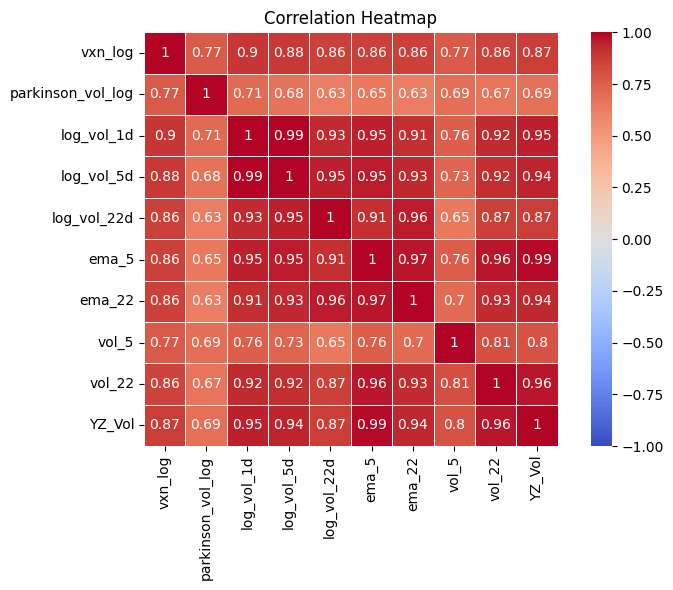

In [ ]:
# calculate correlation matrix and make a plot
corr = df.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True
)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# **Train-Test Split**

In [ ]:
# Define split point
n = len(ndx['Returns'])

train_end = int(n * 0.8)
val_end = int(n * 0.9)

train = df.iloc[:train_end]
val = df.iloc[train_end:val_end]
test = df.iloc[val_end:]

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5229 entries, 2001-01-24 to 2021-11-03
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   vxn_log            5229 non-null   float64
 1   parkinson_vol_log  5229 non-null   float64
 2   log_vol_1d         5229 non-null   float64
 3   log_vol_5d         5229 non-null   float64
 4   log_vol_22d        5229 non-null   float64
 5   ema_5              5229 non-null   float64
 6   ema_22             5229 non-null   float64
 7   vol_5              5229 non-null   float64
 8   vol_22             5229 non-null   float64
 9   YZ_Vol             5229 non-null   float64
dtypes: float64(10)
memory usage: 449.4 KB


In [ ]:
val.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 654 entries, 2021-11-04 to 2024-06-12
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   vxn_log            654 non-null    float64
 1   parkinson_vol_log  654 non-null    float64
 2   log_vol_1d         654 non-null    float64
 3   log_vol_5d         654 non-null    float64
 4   log_vol_22d        654 non-null    float64
 5   ema_5              654 non-null    float64
 6   ema_22             654 non-null    float64
 7   vol_5              654 non-null    float64
 8   vol_22             654 non-null    float64
 9   YZ_Vol             654 non-null    float64
dtypes: float64(10)
memory usage: 56.2 KB


In [ ]:
test.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 388 entries, 2024-06-13 to 2025-12-30
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   vxn_log            388 non-null    float64
 1   parkinson_vol_log  388 non-null    float64
 2   log_vol_1d         388 non-null    float64
 3   log_vol_5d         388 non-null    float64
 4   log_vol_22d        388 non-null    float64
 5   ema_5              388 non-null    float64
 6   ema_22             388 non-null    float64
 7   vol_5              388 non-null    float64
 8   vol_22             388 non-null    float64
 9   YZ_Vol             388 non-null    float64
dtypes: float64(10)
memory usage: 33.3 KB


# **Scaling Features**

In [ ]:
# apply scaler
scaler = StandardScaler()

# align index

train_data = df.loc[train.index].copy()
val_data = df.loc[val.index].copy()
test_data  = df.loc[test.index].copy()

# Fit on train
train_scaled = scaler.fit_transform(train_data)

df_train_scaled = pd.DataFrame(
    train_scaled,
    index=train_data.index,
    columns=train_data.columns
)

# Transform val
val_scaled = scaler.transform(val_data)

df_val_scaled = pd.DataFrame(
    val_scaled,
    index=val_data.index,
    columns=val_data.columns
)

# Transform test
test_scaled = scaler.transform(test_data)

df_test_scaled = pd.DataFrame(
    test_scaled,
    index=test_data.index,
    columns=test_data.columns
)

# **Fit GMM**

In [ ]:
def optimize_gmm_fixed_components(X, covariance_types=None, random_state=42):
    """
    Performs a grid search over different GMM covariance types
    holding the number of components fixed at 2.

    Parameters:
    -----------
    X : array-like or DataFrame of shape (n_samples, n_features)
        The input feature data.
    covariance_types : list, optional
        List of covariance types to test. Defaults to ['full', 'tied', 'diag', 'spherical'].
    random_state : int, optional
        Seed for reproducibility. Default is 42.

    Returns:
    --------
    best_gmm : GaussianMixture object
        The fitted 2-component GMM model with the lowest BIC score.
    df_results : pd.DataFrame
        A dataframe containing the metrics for all tested covariance types, sorted by BIC.
    """
    # Set default covariance search space if none provided
    if covariance_types is None:
        covariance_types = ['full', 'tied', 'diag', 'spherical']

    results = []
    best_bic = float('inf')
    best_gmm = None

    print("Running GMM Covariance Search (n_components fixed at 2)...")

    # Loop only through covariance types since n_components is fixed
    for cov_type in covariance_types:
        # Initialize and fit with exactly 2 components
        gmm = GaussianMixture(n_components=2, covariance_type=cov_type, random_state=random_state)
        gmm.fit(X)

        # Calculate metrics
        bic = gmm.bic(X)
        log_likelihood = gmm.score(X)

        results.append({
            'covariance_type': cov_type,
            'n_components': 2,
            'BIC': bic,
            'Log-Likelihood': log_likelihood
        })

        # Track best model based on lowest BIC
        if bic < best_bic:
            best_bic = bic
            best_gmm = gmm

    # Format and sort results DataFrame
    df_results = pd.DataFrame(results).sort_values(by='BIC', ascending=True).reset_index(drop=True)

    print("\n--- Evaluation Complete ---")
    print(f"Best Covariance Type for 2 Components: {best_gmm.covariance_type}")
    print(f"Best BIC Score: {best_bic:.2f}\n")

    return best_gmm, df_results

In [ ]:
import itertools

def find_best_feature_set(df, feature_pool, min_features=1, max_features=None):
    """
    Evaluates different combinations of features using a 2-component GMM
    to find the feature set that minimizes BIC.

    Parameters:
    -----------
    df : pd.DataFrame
        The full dataframe containing your data.
    feature_pool : list
        The list of all potential feature names to test.
    min_features : int
        Minimum number of features per combination.
    max_features : int
        Maximum number of features per combination. Defaults to len(feature_pool).
    """
    if max_features is None:
        max_features = len(feature_pool)

    feature_selection_results = []

    best_overall_bic = float('inf')
    best_overall_gmm = None
    best_overall_features = None

    # Generate all possible feature combinations within the size constraints
    for r in range(min_features, max_features + 1):
        for feature_subset in itertools.combinations(feature_pool, r):
            feature_subset = list(feature_subset)

            # Extract the actual data matrix for this specific subset
            X_subset = df[feature_subset].values

            # Run your existing GMM covariance search function on this subset
            best_gmm_for_subset, _ = optimize_gmm_fixed_components(X_subset)

            # Recalculate BIC for comparison
            current_bic = best_gmm_for_subset.bic(X_subset)

            feature_selection_results.append({
                'feature_count': len(feature_subset),
                'features': feature_subset,
                'best_covariance': best_gmm_for_subset.covariance_type,
                'BIC': current_bic
            })

            # Track the absolute best combination
            if current_bic < best_overall_bic:
                best_overall_bic = current_bic
                best_overall_gmm = best_gmm_for_subset
                best_overall_features = feature_subset

    # Format and sort results
    df_feature_results = pd.DataFrame(feature_selection_results).sort_values(by='BIC').reset_index(drop=True)

    print("\n==========================================")
    print("      FEATURE SELECTION COMPLETE          ")
    print("==========================================")
    print(f"Best Feature Set: {best_overall_features}")
    print(f"Best Covariance Type: {best_overall_gmm.covariance_type}")
    print(f"Lowest BIC Score: {best_overall_bic:.2f}\n")

    return best_overall_gmm, best_overall_features, df_feature_results

## 9 features

In [ ]:
# Best model
cols = ['vxn_log','parkinson_vol_log', 'rv_1d', 'rv_5d', 'rv_22d', 'ema_5', 'ema_22', 'vol_5', 'vol_22']
df_train_9 = df_train_scaled[cols]
df_val_9 = df_val_scaled[cols]

gmm_9, _ = optimize_gmm_fixed_components(df_train_9)
print(gmm_9)

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: -7513.85

GaussianMixture(n_components=2, random_state=42)


In [ ]:
# Predict the regimes
labels_train_9 = gmm_9.predict(df_train_9)
labels_val_9 = gmm_9.predict(df_val_9)

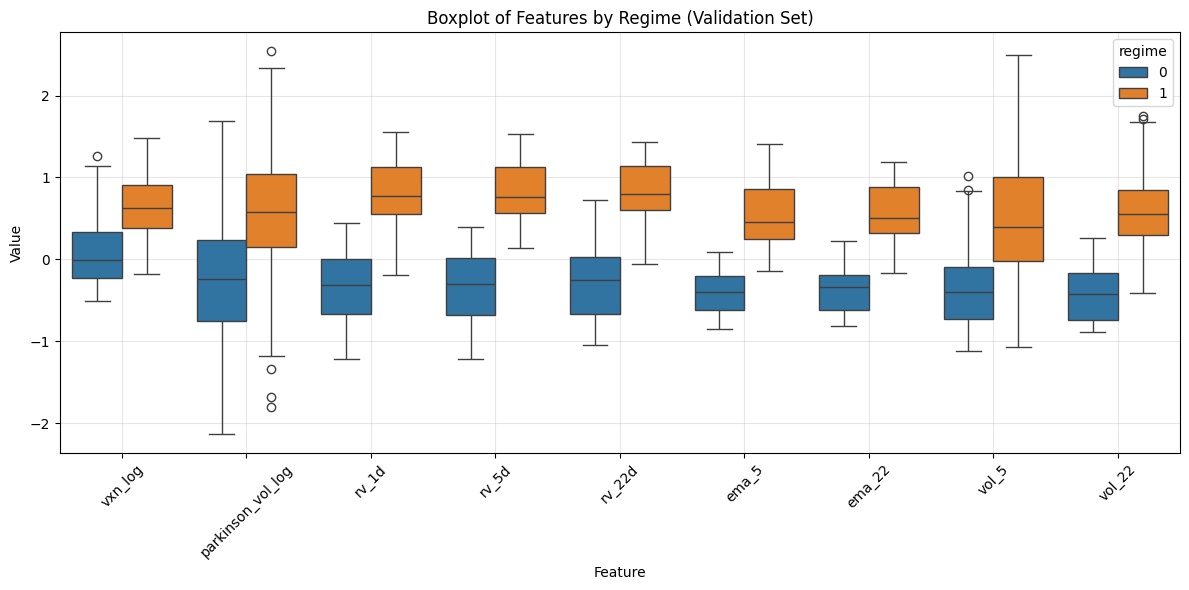

In [ ]:
# Combine features + regime into one DataFrame
df_plot = df_val_9.copy()
df_plot["regime"] = labels_val_9

# Melt into long format
df_melt = df_plot.melt(id_vars="regime", var_name="Feature", value_name="Value")

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_melt,
    x="Feature",
    y="Value",
    hue="regime"
)

plt.title("Boxplot of Features by Regime (Validation Set)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Mean log-likelihood
mean_l9 = gmm_9.score(df_val_9)

## 8 features

In [ ]:
# Best model
cols = ['vxn_log', 'rv_1d', 'rv_5d', 'rv_22d', 'ema_5', 'ema_22', 'vol_5', 'vol_22']
df_train_8 = df_train_scaled[cols]
df_val_8 = df_val_scaled[cols]

gmm_8, _ = optimize_gmm_fixed_components(df_train_8)
print(gmm_8)

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: -15957.58

GaussianMixture(n_components=2, random_state=42)


In [ ]:
# Predict the regimes
labels_train_8 = gmm_8.predict(df_train_8)
labels_val_8 = gmm_8.predict(df_val_8)

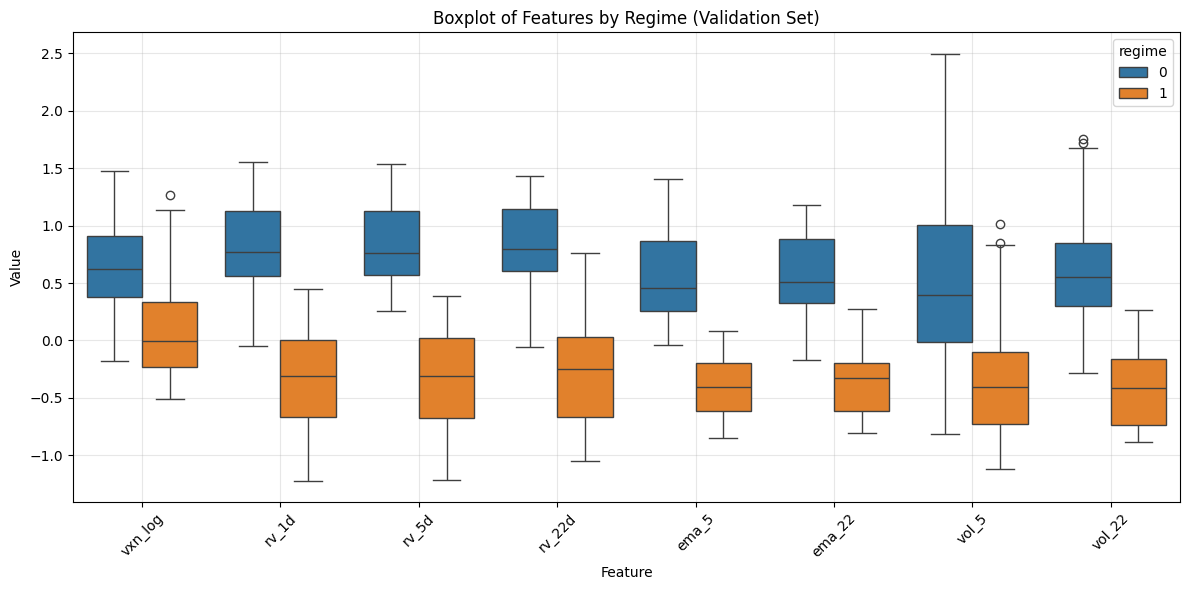

In [ ]:
# Combine features + regime into one DataFrame
df_plot = df_val_8.copy()
df_plot["regime"] = labels_val_8

# Melt into long format
df_melt = df_plot.melt(id_vars="regime", var_name="Feature", value_name="Value")

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_melt,
    x="Feature",
    y="Value",
    hue="regime"
)

plt.title("Boxplot of Features by Regime (Validation Set)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Mean log-likelihood
mean_l8 = gmm_8.score(df_val_8)

## 7 features

In [ ]:
best_model_7, best_features_7, _ = find_best_feature_set(
    df=df_train_8,
    feature_pool=cols,
    min_features=7,
    max_features=7
)

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: -13298.90

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: -21216.18

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: -773.20

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 387.33

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: -6129.60

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: -1851.06

Running GMM Covariance Search (n_components fixed at 

In [ ]:
# Best model
df_train_7 = df_train_scaled[best_features_7]
df_val_7 = df_val_scaled[best_features_7]

gmm_7, _ = optimize_gmm_fixed_components(df_train_7)
print(gmm_7)

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: -21216.18

GaussianMixture(n_components=2, random_state=42)


In [ ]:
# Predict the regimes
labels_train_7 = gmm_7.predict(df_train_7)
labels_val_7 = gmm_7.predict(df_val_7)

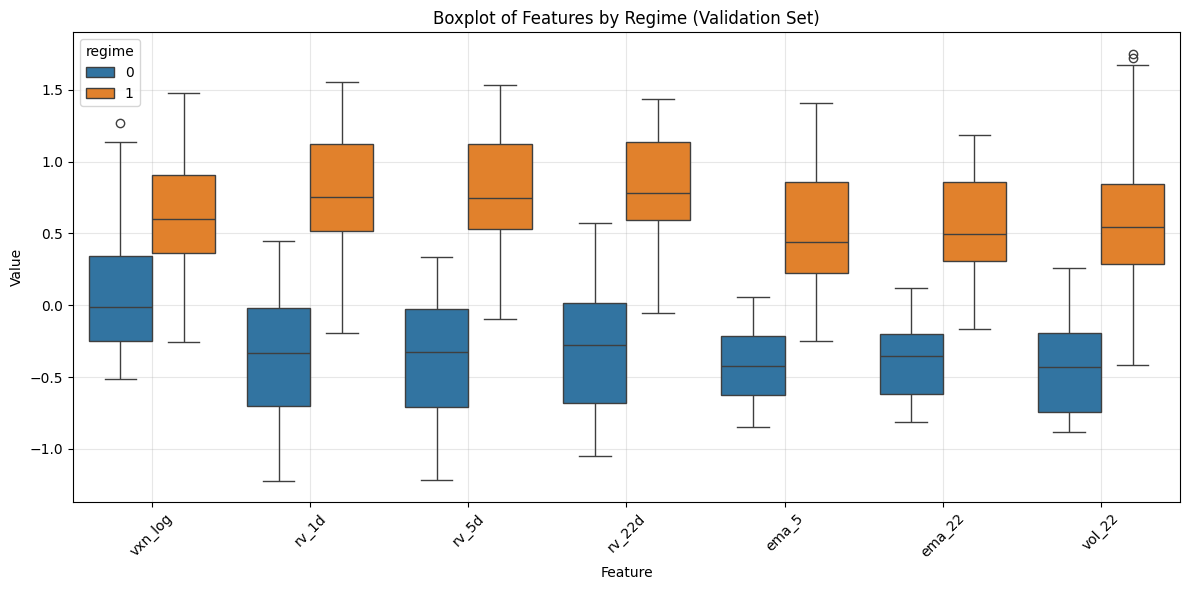

In [ ]:
# Combine features + regime into one DataFrame
df_plot = df_val_7.copy()
df_plot["regime"] = labels_val_7

# Melt into long format
df_melt = df_plot.melt(id_vars="regime", var_name="Feature", value_name="Value")

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_melt,
    x="Feature",
    y="Value",
    hue="regime"
)

plt.title("Boxplot of Features by Regime (Validation Set)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Mean log-likelihood
mean_l7 = gmm_7.score(df_val_7)

## 6 features

In [ ]:
best_model_6, best_features_6, _ = find_best_feature_set(
    df=df_train_8,
    feature_pool=cols,
    min_features=6,
    max_features=6
)

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: -19357.82

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 1970.09

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: -5904.08

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 2757.50

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: -4947.96

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 12160.33

Running GMM Covariance Search (n_components fixed at 

In [ ]:
df_train_6 = df_train_scaled[best_features_6]
df_val_6 = df_val_scaled[best_features_6]

gmm_6, _ = optimize_gmm_fixed_components(df_train_6)
print(gmm_6)

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: -24278.66

GaussianMixture(n_components=2, random_state=42)


In [ ]:
# Predict the regimes
labels_train_6 = gmm_6.predict(df_train_6)
labels_val_6 = gmm_6.predict(df_val_6)

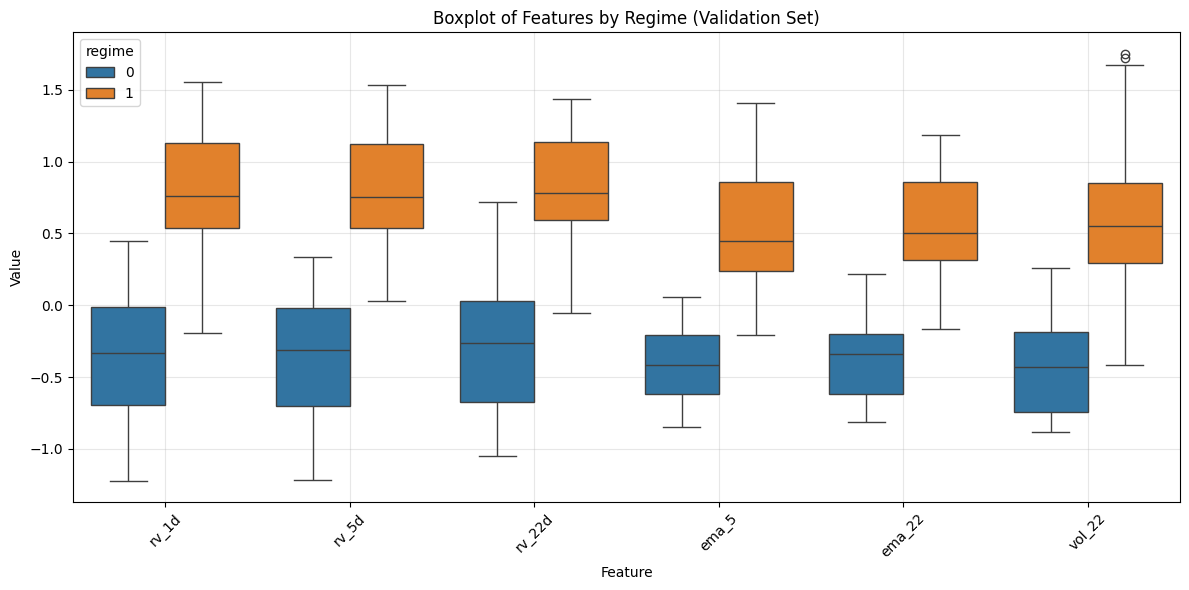

In [ ]:
# Combine features + regime into one DataFrame
df_plot = df_val_6.copy()
df_plot["regime"] = labels_val_6

# Melt into long format
df_melt = df_plot.melt(id_vars="regime", var_name="Feature", value_name="Value")

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_melt,
    x="Feature",
    y="Value",
    hue="regime"
)

plt.title("Boxplot of Features by Regime (Validation Set)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Mean log-likelihood
mean_l6 = gmm_6.score(df_val_6)

##5 features

In [ ]:
best_model_5, best_features_5, _ = find_best_feature_set(
    df=df_train_8,
    feature_pool=cols,
    min_features=5,
    max_features=5
)


Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: -3963.34

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: -3423.17

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 14287.68

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 7213.13

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: -9357.46

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 2770.13

Running GMM Covariance Search (n_components fixed at 2

In [ ]:
df_train_5 = df_train_scaled[best_features_5]
df_val_5 = df_val_scaled[best_features_5]

gmm_5, _ = optimize_gmm_fixed_components(df_train_5)
print(gmm_5)

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: -22578.14

GaussianMixture(n_components=2, random_state=42)


In [ ]:
# Predict the regimes
labels_train_5 = gmm_5.predict(df_train_5)
labels_val_5 = gmm_5.predict(df_val_5)

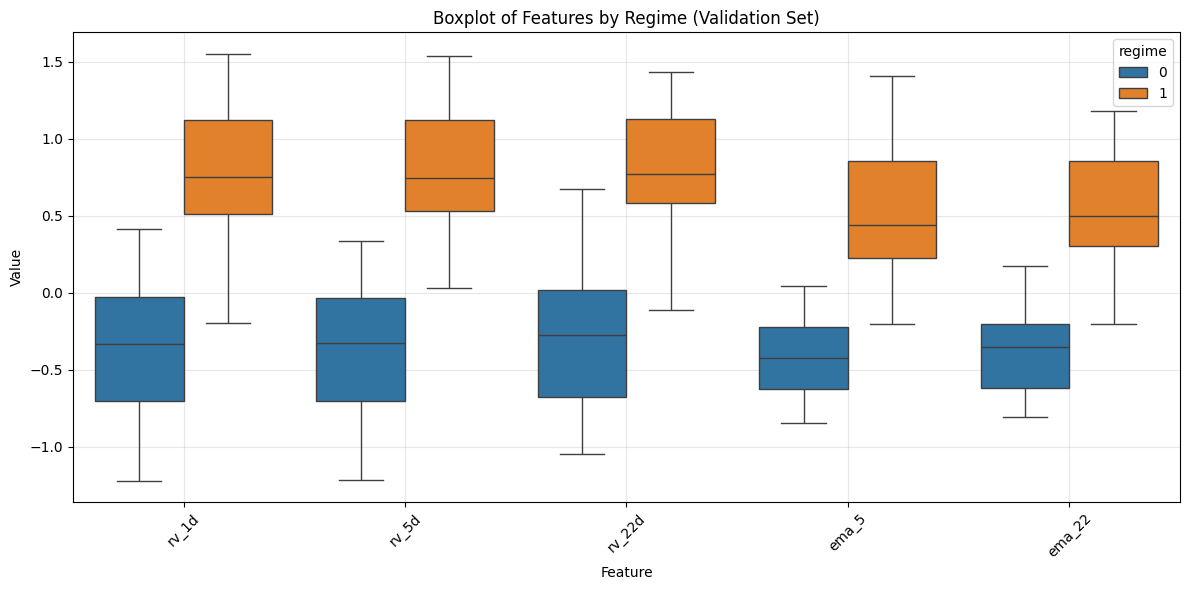

In [ ]:
# Combine features + regime into one DataFrame
df_plot = df_val_5.copy()
df_plot["regime"] = labels_val_5

# Melt into long format
df_melt = df_plot.melt(id_vars="regime", var_name="Feature", value_name="Value")

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_melt,
    x="Feature",
    y="Value",
    hue="regime"
)

plt.title("Boxplot of Features by Regime (Validation Set)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Mean log-likelihood
mean_l5 = gmm_5.score(df_val_5)

## 4 features

In [ ]:
best_model_4, best_features_4, _ = find_best_feature_set(
    df=df_train_8,
    feature_pool=cols,
    min_features=4,
    max_features=4
)


Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 8228.32

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: -3240.11

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 4714.83

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 14882.27

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 7735.28

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 9586.74

Running GMM Covariance Search (n_components fixed at 2).

In [ ]:
df_train_4 = df_train_scaled[best_features_4]
df_val_4 = df_val_scaled[best_features_4]

gmm_4, _ = optimize_gmm_fixed_components(df_train_4)
print(gmm_4)

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: -12853.30

GaussianMixture(n_components=2, random_state=42)


In [ ]:
# Predict the regimes
labels_train_4 = gmm_4.predict(df_train_4)
labels_val_4 = gmm_4.predict(df_val_4)

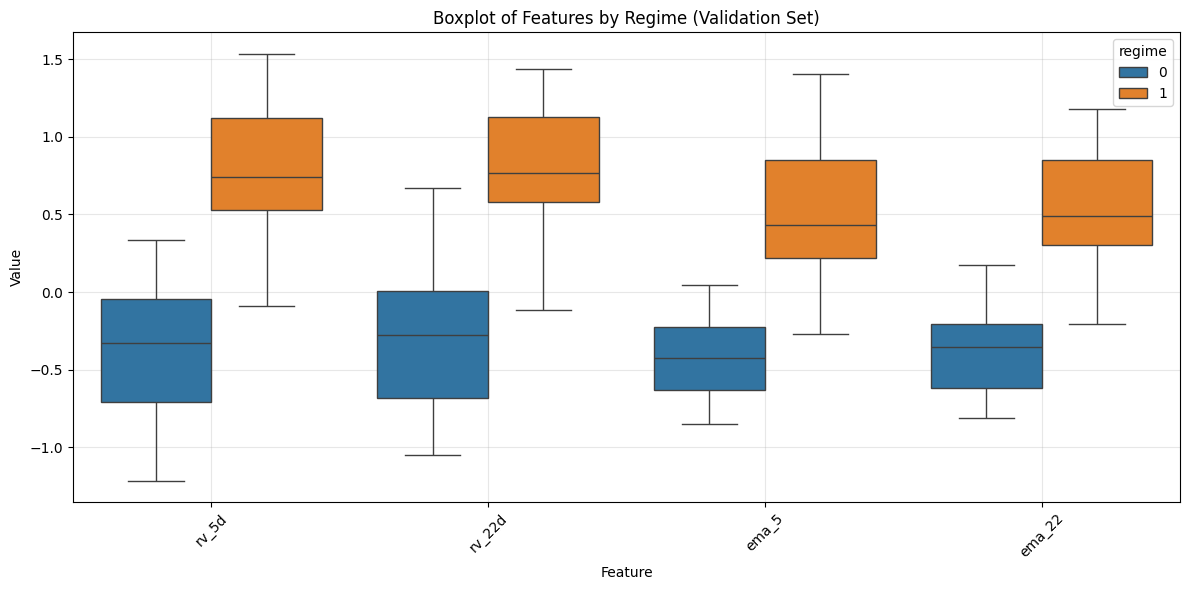

In [ ]:
# Combine features + regime into one DataFrame
df_plot = df_val_4.copy()
df_plot["regime"] = labels_val_4

# Melt into long format
df_melt = df_plot.melt(id_vars="regime", var_name="Feature", value_name="Value")

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_melt,
    x="Feature",
    y="Value",
    hue="regime"
)

plt.title("Boxplot of Features by Regime (Validation Set)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Mean log-likelihood
mean_l4 = gmm_4.score(df_val_4)

## 3 features


In [ ]:
best_model_3, best_features_3, _ = find_best_feature_set(
    df=df_train_8,
    feature_pool=cols,
    min_features=3,
    max_features=3
)


Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 8909.35

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 20877.60

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 8706.59

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 16519.09

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 23938.87

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 16156.13

Running GMM Covariance Search (n_components fixed at 2

In [ ]:
df_train_3 = df_train_scaled[best_features_3]
df_val_3 = df_val_scaled[best_features_3]

gmm_3, _ = optimize_gmm_fixed_components(df_train_3)
print(gmm_3)

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: -7319.87

GaussianMixture(n_components=2, random_state=42)


In [ ]:
# Predict the regimes
labels_train_3 = gmm_3.predict(df_train_3)
labels_val_3 = gmm_3.predict(df_val_3)

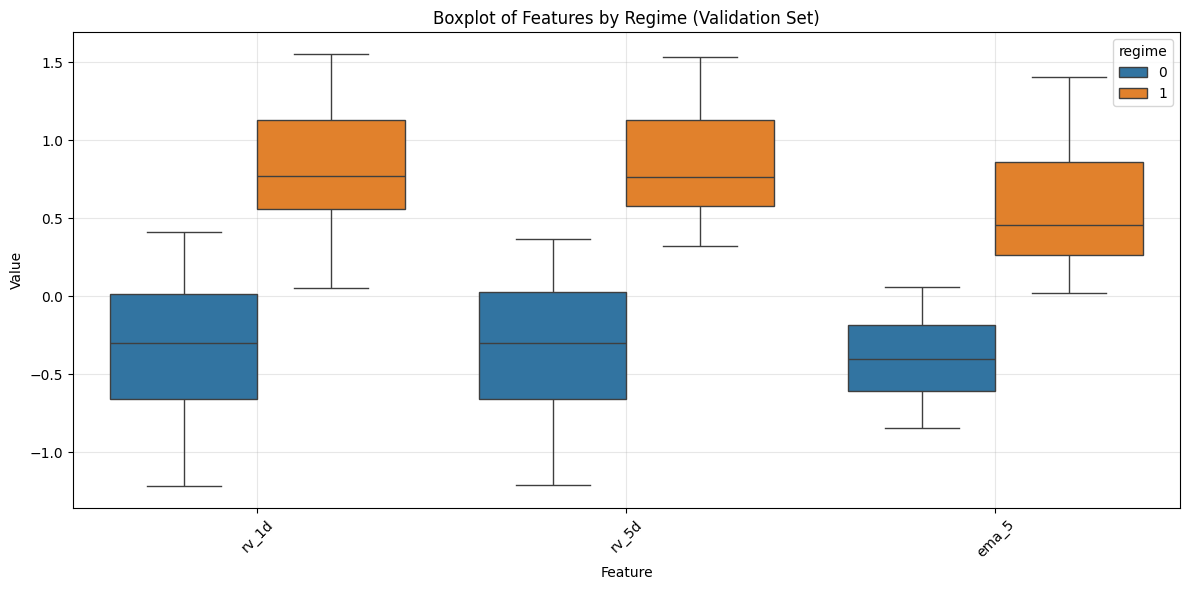

In [ ]:
# Combine features + regime into one DataFrame
df_plot = df_val_3.copy()
df_plot["regime"] = labels_val_3

# Melt into long format
df_melt = df_plot.melt(id_vars="regime", var_name="Feature", value_name="Value")

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_melt,
    x="Feature",
    y="Value",
    hue="regime"
)

plt.title("Boxplot of Features by Regime (Validation Set)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Mean log-likelihood
mean_l3 = gmm_3.score(df_val_3)

## 2 features

In [ ]:
best_model_2, best_features_2, _ = find_best_feature_set(
    df=df_train_8,
    feature_pool=cols,
    min_features=2,
    max_features=2
)


Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 17628.76

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 18189.00

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 19109.53

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 15383.61

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 15699.18

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 19249.01

Running GMM Covariance Search (n_components fixed at

In [ ]:
df_train_2 = df_train_scaled[best_features_2]
df_val_2 = df_val_scaled[best_features_2]

gmm_2, _ = optimize_gmm_fixed_components(df_train_2)
print(gmm_2)

Running GMM Covariance Search (n_components fixed at 2)...

--- Evaluation Complete ---
Best Covariance Type for 2 Components: full
Best BIC Score: 842.75

GaussianMixture(n_components=2, random_state=42)


In [ ]:
# Predict the regimes
labels_train_2 = gmm_2.predict(df_train_2)
labels_val_2 = gmm_2.predict(df_val_2)

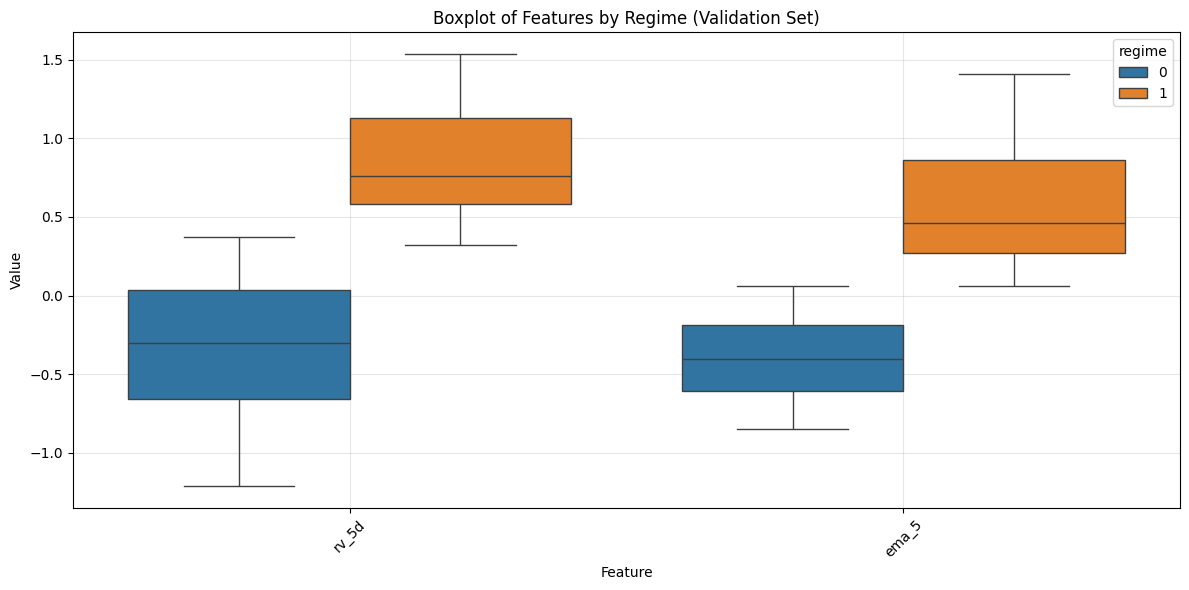

In [ ]:
# Combine features + regime into one DataFrame
df_plot = df_val_2.copy()
df_plot["regime"] = labels_val_2

# Melt into long format
df_melt = df_plot.melt(id_vars="regime", var_name="Feature", value_name="Value")

plt.figure(figsize=(12, 6))
sns.boxplot(
    data=df_melt,
    x="Feature",
    y="Value",
    hue="regime"
)

plt.title("Boxplot of Features by Regime (Validation Set)")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Mean log-likelihood
mean_l2 = gmm_2.score(df_val_2)

# **Final Model**

In [ ]:
def highlight_min(s):
    return ['font-weight: bold' if v == s.min() else '' for v in s]

def highlight_max(s):
    return ['font-weight: bold' if v == s.max() else '' for v in s]

In [ ]:
# dataframe for information criteria and Mean log-likelihood
df_score = pd.DataFrame({
    "Mean Log-Likelihood": [mean_l9, mean_l8, mean_l7, mean_l6, mean_l5, mean_l4, mean_l3, mean_l2]
}, index=["Model 9", "Model 8", "Model 7", "Model 6", "Model 5", "Model 4", "Model 3", "Model 2"])

In [ ]:
# Highlight model with lowest AIC, BIC and highest Log-Likelihood
df_score_style = (
    df_score.round(4).style
        .apply(highlight_max, subset=["Mean Log-Likelihood"])
)
df_score_style

,Mean Log-Likelihood
Model 9,-0.670600
Model 8,0.228800
Model 7,0.874100
Model 6,1.657200
Model 5,1.515300
Model 4,0.499300
Model 3,0.336600
Model 2,-0.522400


In [ ]:
# Get the probability of each sample belonging to each regime
df_test_6 = df_test_scaled[best_features_6]
probs_train = gmm_6.predict_proba(df_train_6)
probs_val = gmm_6.predict_proba(df_val_6)
probs_test = gmm_6.predict_proba(df_test_6)

In [ ]:
# convert to df
probs_test_df = pd.DataFrame(
    probs_test,
    index=df_test_6.index,
    columns=["prob_regime_0", "prob_regime_1"]
)

probs_test_df.head()

,prob_regime_0,prob_regime_1
Date,,
2023-05-23,1.0,1.924964e-08
2023-05-24,1.0,2.510812e-08
2023-05-25,1.0,1.181560e-08
2023-05-26,1.0,6.590845e-08
2023-05-30,1.0,5.116243e-08


In [ ]:
# Check which regime is which
df_test = df_test_6.copy()
labels_test_6 = gmm_6.predict(df_test_6)
df_test["regime"] = labels_test_6
df_test.groupby("regime").mean().round(4)

,rv_1d,rv_5d,rv_22d,ema_5,ema_22,vol_22
regime,,,,,,
0,-0.3973,-0.4022,-0.4001,-0.4507,-0.4521,-0.4167
1,0.8261,0.8424,0.7744,0.6344,0.5563,0.4714


In [ ]:
# Check which regime is which
df_val = df_val_6.copy()
df_val["regime"] = labels_val_6
df_val.groupby("regime").mean().round(4)

,rv_1d,rv_5d,rv_22d,ema_5,ema_22,vol_22
regime,,,,,,
0,-0.3369,-0.3387,-0.2867,-0.4025,-0.3753,-0.4349
1,0.8206,0.8279,0.8328,0.5466,0.5583,0.5839


In [ ]:
# Check which regime is which
df_train = df_train_6.copy()
df_train["regime"] = labels_train_6
df_train.groupby("regime").mean().round(4)

,rv_1d,rv_5d,rv_22d,ema_5,ema_22,vol_22
regime,,,,,,
0,-0.5638,-0.5669,-0.5623,-0.5280,-0.5347,-0.5097
1,1.1927,1.1992,1.1896,1.1169,1.1311,1.0783


Regime 1 is crisis, regime 0 is calm.

# **Model Inspection**

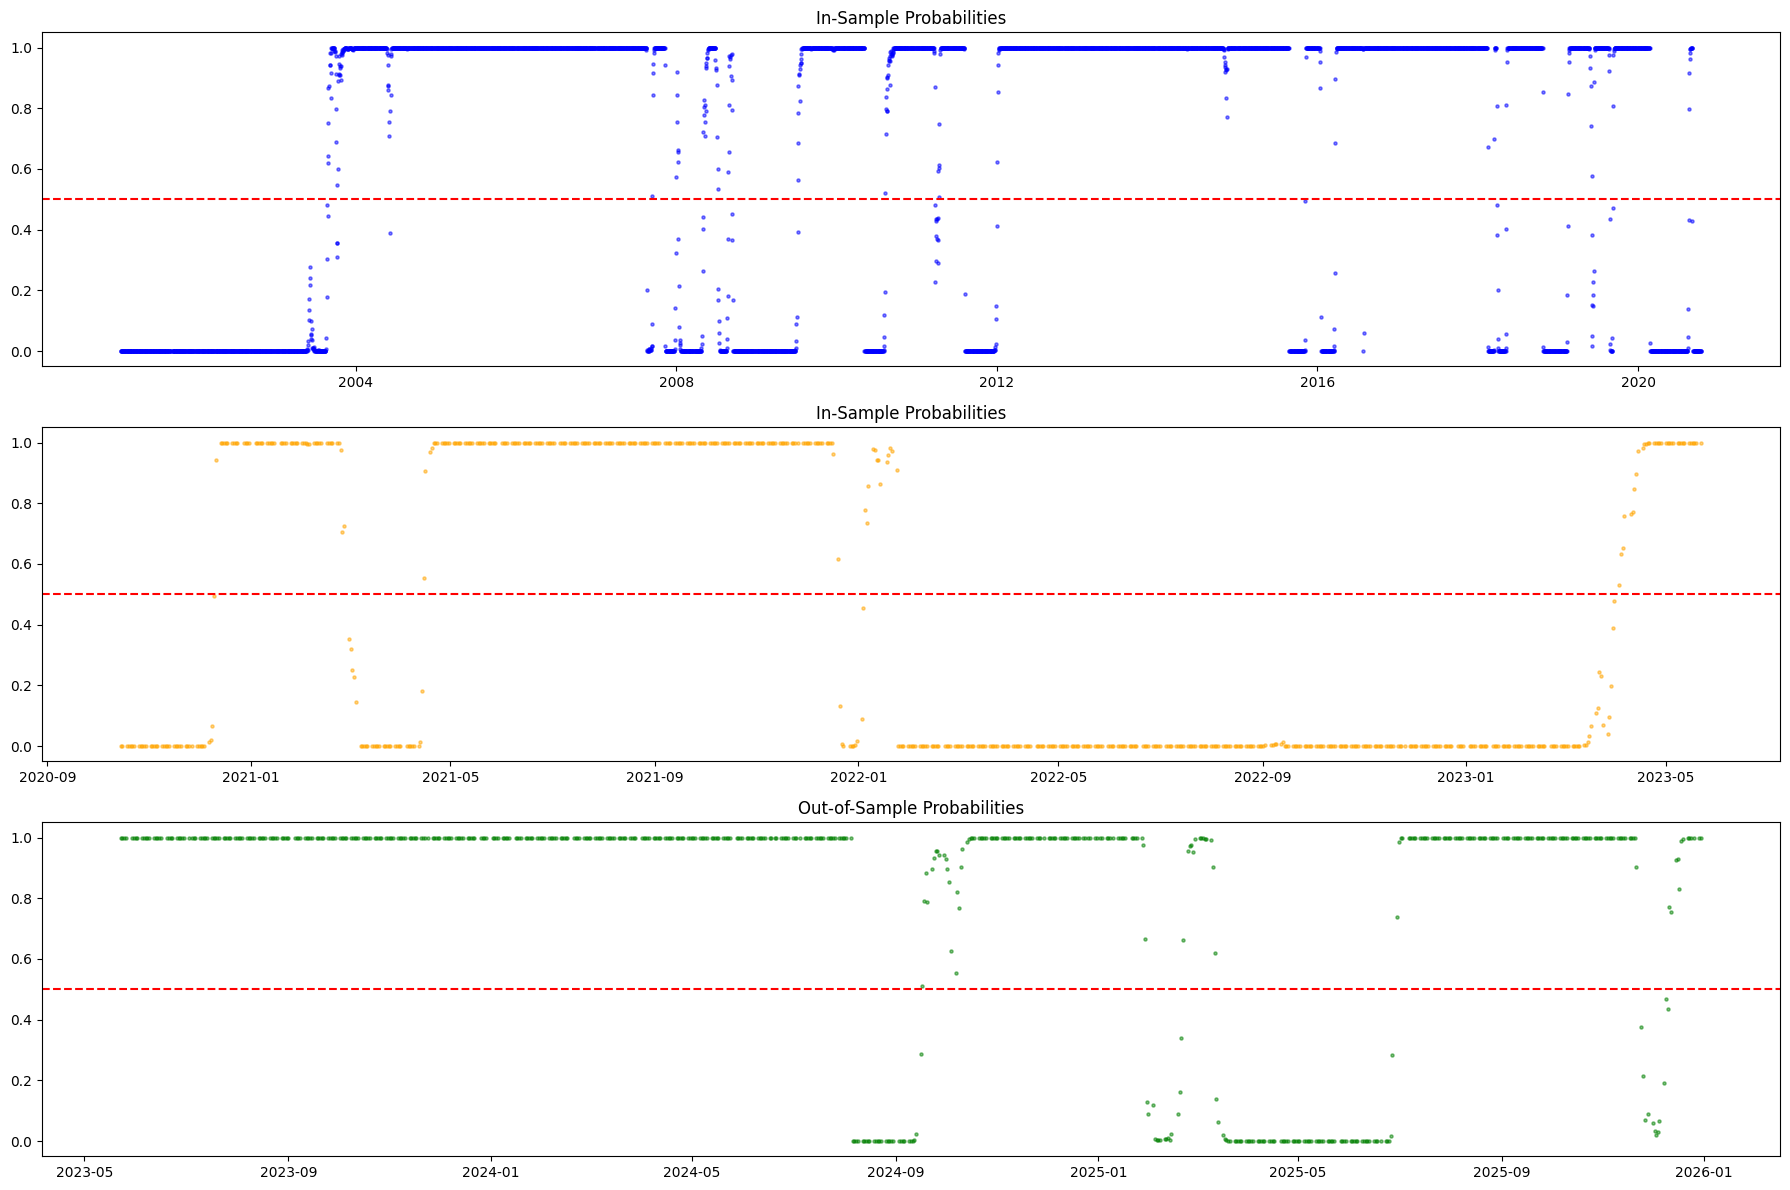

In [ ]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(18, 12), sharey=True)

# Plot Training Set
ax1.scatter(df_train.index, probs_train[:, 0], s=5, color='blue', alpha=0.5)
ax1.axhline(0.5, color='red', linestyle='--')
ax1.set_title('In-Sample Probabilities')

# Plot Val Set
ax2.scatter(df_val.index, probs_val[:, 0], s=5, color='orange', alpha=0.5)
ax2.axhline(0.5, color='red', linestyle='--')
ax2.set_title('In-Sample Probabilities')

# Plot Test Set
ax3.scatter(df_test.index, probs_test[:, 0], s=5, color='green', alpha=0.5)
ax3.axhline(0.5, color='red', linestyle='--')
ax3.set_title('Out-of-Sample Probabilities')

plt.tight_layout()
plt.show()

In [ ]:
# Create a boolean mask for probabilities between 0.4 and 0.6
uncertain_points = (probs_train[:, 0] >= 0.4) & (probs_train[:, 0] <= 0.6)

# Calculate percentage
percent_uncertain = np.mean(uncertain_points) * 100

print(f"In-Sample Ambiguity Rate (0.4 - 0.6): {percent_uncertain:.2f}%")

In-Sample Ambiguity Rate (0.4 - 0.6): 0.60%


In [ ]:
# Create a boolean mask for probabilities between 0.4 and 0.6
uncertain_points = (probs_val[:, 0] >= 0.4) & (probs_val[:, 0] <= 0.6)

# Calculate percentage
percent_uncertain = np.mean(uncertain_points) * 100

print(f"In-Sample Ambiguity Rate (0.4 - 0.6): {percent_uncertain:.2f}%")

In-Sample Ambiguity Rate (0.4 - 0.6): 0.76%


In [ ]:
# Create a boolean mask for probabilities between 0.4 and 0.6
uncertain_points = (probs_test[:, 0] >= 0.4) & (probs_test[:, 0] <= 0.6)

# Calculate percentage
percent_uncertain = np.mean(uncertain_points) * 100

print(f"Out-of-Sample Ambiguity Rate (0.4 - 0.6) : {percent_uncertain:.2f}%")

Out-of-Sample Ambiguity Rate (0.4 - 0.6) : 0.61%


In [ ]:
probs_predict = pd.read_pickle('/content/drive/MyDrive/Thesis/probs_test.pkl')
probs_predict.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 654 entries, 2023-05-23 to 2025-12-30
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   prob_regime_0  654 non-null    float64
 1   prob_regime_1  654 non-null    float64
dtypes: float64(2)
memory usage: 15.3 KB


# **Ensemble Model**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## AR-GARCH-skewt Predictions

In [ ]:
# Rolling window forecasting
results_garch= []
window = 750

for t in range(val_end, len(ndx)):

    returns = ndx['Returns'].copy()

    # Rolling window:
    train_window = returns.iloc[t - window:t]

    # Get the index label of the target observation we are forecasting for
    target_index = returns.index[t]

    model = arch_model(
        train_window,
        mean    = "ARX",
        lags    = 1,
        vol     = "GARCH",
        p       = 1,
        q       = 1,
        dist    = "skewt")

    result = model.fit(disp='off', show_warning=False)

    try:
        params = result.params

        valid = (
        np.isfinite(result.params).all() and
        result.convergence_flag == 0
        )

        if not valid:
          continue

        forecast = result.forecast(horizon=1)
        sigma2 = forecast.variance.iloc[-1, 0]
        sigma = np.sqrt(sigma2)

        if np.isnan(sigma):
            continue

        # Append the original index alongside the metrics
        results_garch.append({
            "target_date": target_index,
            "volatility": sigma
        })

    except (KeyError, ValueError, AttributeError):
        continue

# Convert the results into a clean DataFrame using the original index structure
df_results_garch = pd.DataFrame(results_garch)
if not df_results_garch.empty:
    df_results_garch.set_index("target_date", inplace=True)

In [ ]:
df_results_garch.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 654 entries, 2023-05-23 to 2025-12-30
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   volatility  654 non-null    float64
dtypes: float64(1)
memory usage: 10.2 KB


## Standalone LSTM Predictions

In [ ]:
lstm_predict = pd.read_pickle('/content/drive/MyDrive/Thesis/lstm_predict.pkl')
lstm_predict.head()

,Actual Volatility,Predicted Volatility
Date,,
2023-08-28,1.005086,1.061661
2023-08-29,0.997276,1.096937
2023-08-30,1.000292,1.016319
2023-08-31,0.997463,0.983849
2023-09-01,0.974569,0.992104


In [ ]:
lstm_predict.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 588 entries, 2023-08-28 to 2025-12-30
Data columns (total 2 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Actual Volatility     588 non-null    float64
 1   Predicted Volatility  588 non-null    float32
dtypes: float32(1), float64(1)
memory usage: 11.5 KB


## Ensemble Prediction

In [ ]:
ensemble_predict = pd.concat(
    [probs_predict,
     lstm_predict['Predicted Volatility'],
     df_results_garch['volatility']],
    axis=1
)
ensemble_predict.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 654 entries, 2023-05-23 to 2025-12-30
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   prob_regime_0         654 non-null    float64
 1   prob_regime_1         654 non-null    float64
 2   Predicted Volatility  588 non-null    float32
 3   volatility            654 non-null    float64
dtypes: float32(1), float64(3)
memory usage: 23.0 KB


In [ ]:
ensemble_predict.dropna(inplace=True)
ensemble_predict.rename(columns={
    "Predicted Volatility": "lstm_predict",
    "volatility": "garch_predict"
}, inplace=True)

ensemble_predict.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 588 entries, 2023-08-28 to 2025-12-30
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   prob_regime_0  588 non-null    float64
 1   prob_regime_1  588 non-null    float64
 2   lstm_predict   588 non-null    float32
 3   garch_predict  588 non-null    float64
dtypes: float32(1), float64(3)
memory usage: 20.7 KB


In [ ]:
ensemble_predict['ensemble_pred'] = (ensemble_predict['lstm_predict'] * ensemble_predict['prob_regime_1']
                                     + ensemble_predict['garch_predict'] * ensemble_predict['prob_regime_0'])

ensemble_predict.head()

,prob_regime_0,prob_regime_1,lstm_predict,garch_predict,ensemble_pred
2023-08-28,0.999999,1.345903e-06,1.061661,1.228792,1.228792
2023-08-29,0.999999,6.850456e-07,1.096937,1.189721,1.189721
2023-08-30,0.999999,9.661274e-07,1.016319,1.289460,1.289460
2023-08-31,0.999999,1.266736e-06,0.983849,1.244195,1.244195
2023-09-01,0.999999,1.086975e-06,0.992104,1.197112,1.197112
